# House Price Prediction System

# Model Training

## Objectives

- Train multiple regression models
- Compare model performance
- Select the best model

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/Housing.csv")

## 3. Data Preprocessing

In [3]:
yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in yes_no_columns:
    df[col] = df[col].map({
        "yes":1,
        "no":0
    })

In [4]:
df["furnishingstatus"] = df["furnishingstatus"].map({
    "furnished":2,
    "semi-furnished":1,
    "unfurnished":0
})

In [5]:
X = df.drop("price", axis=1)

y = df["price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 4. Train Linear Regression

In [7]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

## 5. Train Decision Tree Regressor

In [8]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

## 6. Train Random Forest Regressor

In [9]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

## 7. Compare Models

In [10]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.649475
1,Decision Tree,0.415999
2,Random Forest,0.612840


In [11]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score
0,Linear Regression,0.649475
2,Random Forest,0.612840
1,Decision Tree,0.415999


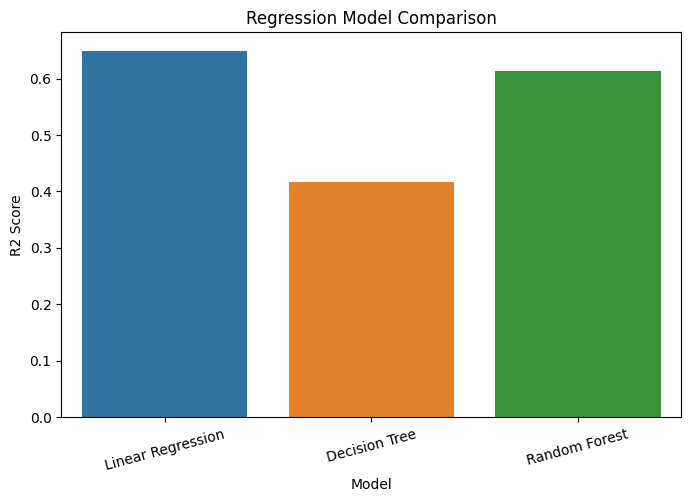

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Model Comparison")

plt.xticks(rotation=15)

plt.show()

## Conclusion

The model with the highest R² Score will be selected for evaluation and deployment.